# Stage 3 — nonlinear embeddings (UMAP / CEBRA)

Visualize the **50 ms smoothed** embeddings (σ=100 ms, speed > 4 cm/s) written by
`src/common/embed_smoothed.py`. CA1 and PFC kept separate. Three embeddings:
**UMAP** (unsupervised), **CEBRA-Time** (unsupervised, `cebratime`), and
**CEBRA** (supervised, trained on position+speed — NOT the novel/familiar label).
The two unsupervised methods carry the honest geometry; supervised CEBRA is the
behaviour-aligned reference.

1. 3-D embeddings per method, coloured by condition and by position
2. CEBRA training-loss curves (both variants)
3. **Position decoding** (kNN, cross-validated) — how much behaviour each
   geometry captures, per method and region
4. **Track ↔ manifold** — 2-D trajectory and 3-D UMAP manifold sharing a
   linearized-position colour map
5. **Interactive 3-D manifold** (plotly) — drag to rotate / zoom / hover

## Setup

In [1]:
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "common" / "config.py").exists())
for _d in ("common", "000447"):
    sys.path.insert(0, str(_root / "src" / _d))
import numpy as np
import matplotlib.pyplot as plt
from config import processed_dir
DATA_PROCESSED = processed_dir("000447")
BIN_MS = 50                       # smoothed fine-bin path (sigma=100 ms, speed > 4 cm/s)
plt.rcParams["figure.dpi"] = 100
COND_COLOR = {"novel": "tab:red", "familiar": "tab:blue"}
# 50 ms embeddings: UMAP + both CEBRA variants (supervised & unsupervised CEBRA-Time)
METHODS = ["umap", "cebratime", "cebra"]
print("bin size:", BIN_MS, "ms")

bin size: 50 ms


## Pick a subject/region and load its embeddings

In [3]:
subjects = sorted({f.stem.split("_")[2] for f in DATA_PROCESSED.glob(f"emb_*_{BIN_MS}ms.npz")})
print("subjects:", subjects)
SUBJECT = subjects[1]   # change me
REGION = "CA1"          # or "PFC"

emb = {}
for m in METHODS:
    f = DATA_PROCESSED / f"emb_{m}_{SUBJECT}_{REGION}_{BIN_MS}ms.npz"
    if f.exists():
        emb[m] = np.load(f, allow_pickle=False)
print(f"{SUBJECT} {REGION}: loaded methods", list(emb))

subjects: ['JDS-NFN-AM2', 'JDS-NFN-JS17', 'JDS-NFN-JS21', 'JDS-NFN-JS34', 'JDS-NFN-ZT2']
JDS-NFN-JS17 CA1: loaded methods ['umap', 'cebratime', 'cebra']


## 1. Embeddings coloured by condition and position

Top row: novel (red) vs familiar (blue). Bottom row: coloured by x-position
(the track), to check the embedding is behaviorally organized.

C:\Users\proskurinm\AppData\Local\Temp\ipykernel_23536\4252759630.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


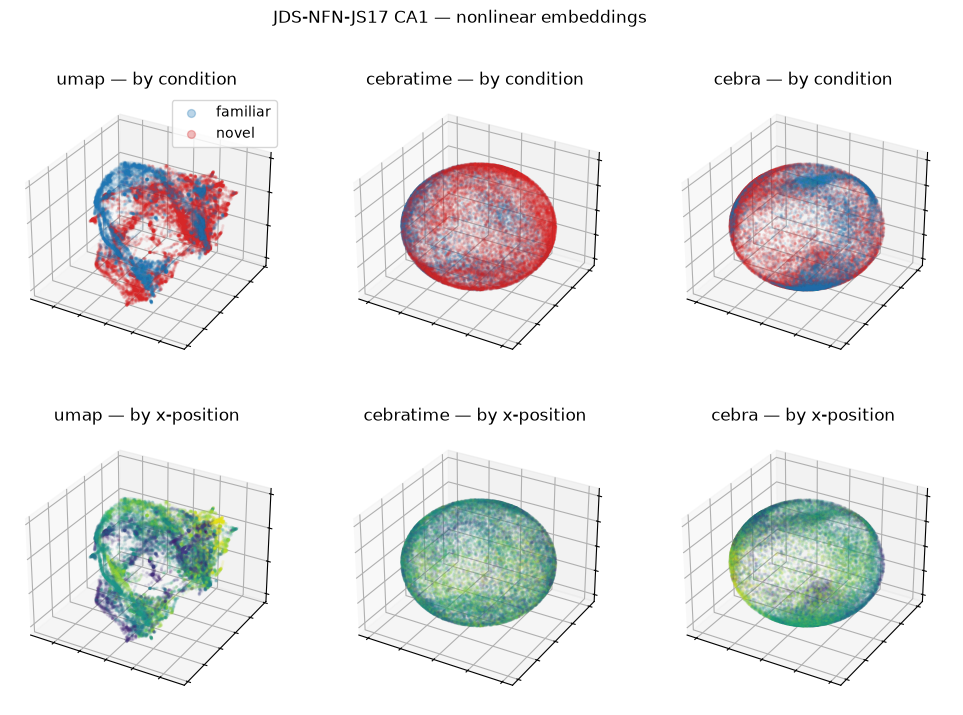

In [4]:
avail = list(emb)
fig = plt.figure(figsize=(4 * len(avail), 8))
for j, m in enumerate(avail):
    e = emb[m]["embedding"]; cond = emb[m]["condition"]; pos = emb[m]["position"]
    ax = fig.add_subplot(2, len(avail), j + 1, projection="3d")
    for c in np.unique(cond):
        mk = cond == c
        ax.scatter(e[mk, 0], e[mk, 1], e[mk, 2], s=2, alpha=0.3,
                   color=COND_COLOR.get(c), label=c)
    ax.set_title(f"{m} — by condition"); ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    if j == 0: ax.legend(markerscale=4)
    ax2 = fig.add_subplot(2, len(avail), len(avail) + j + 1, projection="3d")
    p = ax2.scatter(e[:, 0], e[:, 1], e[:, 2], s=2, alpha=0.3, c=pos[:, 0], cmap="viridis")
    ax2.set_title(f"{m} — by x-position"); ax2.set_xticklabels([]); ax2.set_yticklabels([]); ax2.set_zticklabels([])
fig.suptitle(f"{SUBJECT} {REGION} — nonlinear embeddings")
plt.tight_layout()

## 2. CEBRA training loss

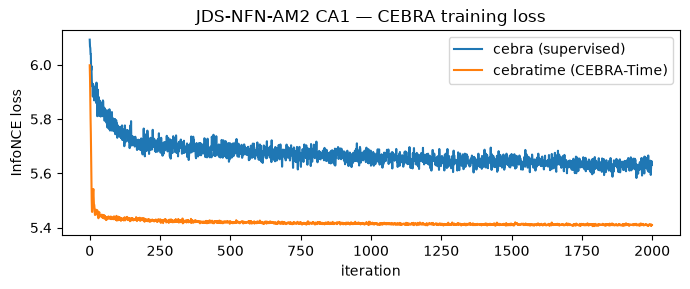

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
plotted = False
for m in ("cebra", "cebratime"):
    if m in emb and "cebra_loss" in emb[m].files:
        ax.plot(emb[m]["cebra_loss"], label=f"{m} ({'supervised' if m=='cebra' else 'CEBRA-Time'})")
        plotted = True
if plotted:
    ax.set_xlabel("iteration"); ax.set_ylabel("InfoNCE loss"); ax.legend()
    ax.set_title(f"{SUBJECT} {REGION} — CEBRA training loss")
    plt.tight_layout()
else:
    print("no CEBRA loss recorded")

## 3. Position decoding (cross-validated kNN)

For every embedding we predict the animal's (x, y) from the embedding with a kNN
regressor (5-fold CV) and report R². Higher = the geometry encodes behavior
better. This is the apples-to-apples comparison across methods and regions.

region,CA1,PFC
method,,
cebra,0.473801,0.329652
cebratime,0.107105,0.222724
umap,0.344835,0.231225


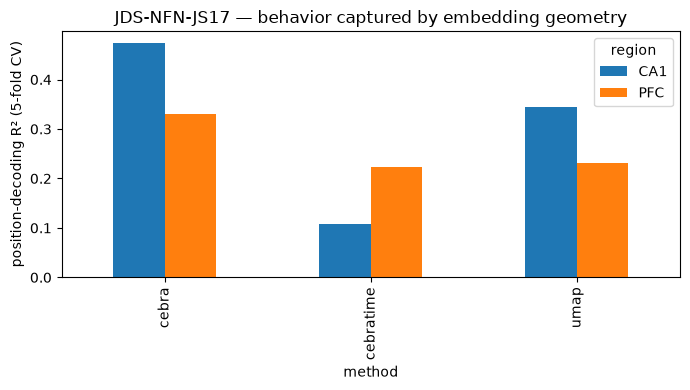

In [5]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

def decode_r2(e, pos):
    ok = np.isfinite(pos).all(axis=1)
    knn = KNeighborsRegressor(n_neighbors=15)
    return cross_val_score(knn, e[ok], pos[ok], cv=5,
                           scoring="r2").mean()

rows = []
for region in ["CA1", "PFC"]:
    for m in METHODS:
        f = DATA_PROCESSED / f"emb_{m}_{SUBJECT}_{region}_{BIN_MS}ms.npz"
        if not f.exists():
            continue
        dd = np.load(f, allow_pickle=False)
        rows.append((region, m, decode_r2(dd["embedding"], dd["position"])))

import pandas as pd
tab = pd.DataFrame(rows, columns=["region", "method", "r2"])
piv = tab.pivot(index="method", columns="region", values="r2")
ax = piv.plot.bar(figsize=(7, 4)); ax.set_ylabel("position-decoding R² (5-fold CV)")
ax.set_title(f"{SUBJECT} — behavior captured by embedding geometry")
plt.tight_layout()
piv

## 4. Track location ↔ neural-manifold location

Left: the animal's 2-D trajectory on one familiar W-track, each sample coloured by
its **linearized** position (left arm → base → centre → base → right arm). Right:
the **3-D** UMAP CA1 manifold for the same samples, coloured by the same
linearized position — so a colour in the manifold tells you where on the track
that activity occurred. Needs the trials table (streams the NWB once) to build the
track graph.

A newer version (0.76.7) of dandi/dandi-cli is available. You are using 0.75.1


Text(0.5, 0.98, 'Track location ↔ neural-manifold location (shared colour = linearized position)')

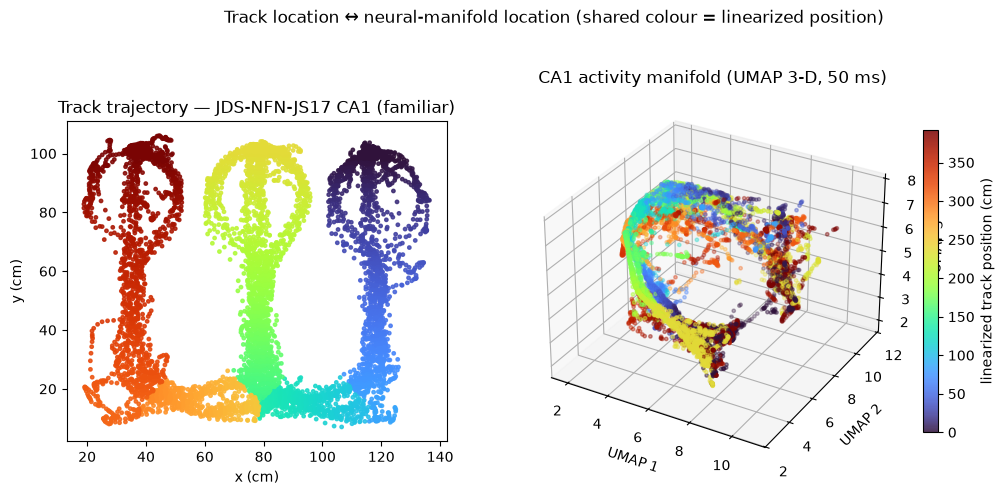

In [6]:
# Track location <-> neural manifold: colour both by LINEARIZED position.
# Single condition (one physical W-track) so the linearization is unambiguous.
import download as dl
import linearize as lz
from importlib import import_module
CONDITION = "familiar"
EPOCH_TABLE = "epoch intervals"

u = emb["umap"]
posc, condc, embc = u["position"], u["condition"], u["embedding"]
mask = condc == CONDITION

asset = next(p for p in dl.list_asset_paths(dandiset_id="000447")
             if p.endswith(".nwb") and p.split("/")[0].replace("sub-", "") == SUBJECT)
with dl.stream_nwb(asset, dandiset_id="000447") as nwb:
    ex = import_module("01_extraction")
    epochs = nwb.intervals[EPOCH_TABLE].to_dataframe().reset_index(drop=True)
    conds = ex.epoch_conditions(nwb.session_description, len(epochs))
    ss = nwb.processing["behavior"].data_interfaces["Position"].spatial_series["SpatialSeries"]
    pos_t = np.asarray(ss.timestamps[:]); pos_xy = np.asarray(ss.data[:])[:, :2]
    trials = nwb.intervals["trials"].to_dataframe().reset_index(drop=True)
    ep_c = epochs[[conds[e] == CONDITION for e in range(len(epochs))]]
    in_c = np.zeros(len(trials), bool); pos_in_c = np.zeros(len(pos_t), bool)
    for _, r in ep_c.iterrows():
        in_c |= (trials.start_time.to_numpy() >= r.start_time) & (trials.start_time.to_numpy() < r.stop_time)
        pos_in_c |= (pos_t >= r.start_time) & (pos_t < r.stop_time)
    wells = lz.wells_from_trials(trials[in_c], pos_t, pos_xy)
    graph, eo, sp, _ = lz.build_wtrack_graph(pos_xy[pos_in_c], wells=wells)
    lin, _ = lz.linearize_position(posc[mask], graph, eo, sp)

ok = np.isfinite(lin) & np.isfinite(posc[mask]).all(axis=1)
P, E, L = posc[mask][ok], embc[mask][ok], lin[ok]
order = np.argsort(L)                      # draw low->high so colour layering is stable

fig = plt.figure(figsize=(13, 5.6))
ax0 = fig.add_subplot(1, 2, 1)
s0 = ax0.scatter(P[order, 0], P[order, 1], c=L[order], cmap="turbo", s=6, alpha=0.85)
ax0.set_aspect("equal"); ax0.set_xlabel("x (cm)"); ax0.set_ylabel("y (cm)")
ax0.set_title(f"Track trajectory — {SUBJECT} CA1 ({CONDITION})")
ax1 = fig.add_subplot(1, 2, 2, projection="3d")
ax1.scatter(E[order, 0], E[order, 1], E[order, 2], c=L[order], cmap="turbo", s=6, alpha=0.7)
ax1.set_xlabel("UMAP 1"); ax1.set_ylabel("UMAP 2"); ax1.set_zlabel("UMAP 3")
ax1.set_title("CA1 activity manifold (UMAP 3-D, 50 ms)")
cb = fig.colorbar(s0, ax=[ax0, ax1], shrink=0.7, pad=0.02)
cb.set_label("linearized track position (cm)")
fig.suptitle("Track location ↔ neural-manifold location (shared colour = linearized position)")

## 5. Interactive 3-D manifold (plotly)

Same data as section 4, but interactive: **drag to rotate** the UMAP manifold,
scroll to zoom, hover for the linearized position. Both panels share the
Turbo colour map (track location ↔ manifold location). Renders inline in
VS Code / Jupyter.

In [8]:
# Interactive version (plotly): drag the manifold to rotate / zoom.
# Reuses P (2-D track), E (3-D UMAP) and L (linearized position) from section 4.
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.42, 0.58],
    specs=[[{"type": "xy"}, {"type": "scene"}]],
    subplot_titles=(f"Track trajectory — {SUBJECT} CA1 ({CONDITION})",
                    "CA1 activity manifold (UMAP 3-D, 50 ms)"))
fig.add_trace(go.Scattergl(
    x=P[:, 0], y=P[:, 1], mode="markers",
    marker=dict(size=4, color=L, coloraxis="coloraxis"),
    hovertemplate="x=%{x:.0f}  y=%{y:.0f}<br>lin=%{marker.color:.0f} cm<extra></extra>"),
    row=1, col=1)
fig.add_trace(go.Scatter3d(
    x=E[:, 0], y=E[:, 1], z=E[:, 2], mode="markers",
    marker=dict(size=2.5, color=L, coloraxis="coloraxis", opacity=0.85),
    hovertemplate="UMAP=(%{x:.1f}, %{y:.1f}, %{z:.1f})<br>lin=%{marker.color:.0f} cm<extra></extra>"),
    row=1, col=2)
fig.update_xaxes(title_text="x (cm)", row=1, col=1)
fig.update_yaxes(title_text="y (cm)", scaleanchor="x", row=1, col=1)
fig.update_layout(
    coloraxis=dict(colorscale="Turbo",
                   colorbar=dict(title="linearized<br>position (cm)")),
    scene=dict(xaxis_title="UMAP 1", yaxis_title="UMAP 2", zaxis_title="UMAP 3"),
    width=1000, height=560, margin=dict(l=0, r=0, t=50, b=0), showlegend=False,
    title_text="Interactive — drag to rotate the manifold (shared colour = linearized position)")
fig                                    # display as the cell's last expression

---
**Next:** stage 4 (`src/04_cross_condition.py`) — Procrustes / CCA to align
novel vs. familiar and CA1 vs. PFC embeddings and quantify the transformation.